# K-Means Clustering — 5 Fitur Audio
**Sistem Rekomendasi Musik NeuMF + K-Means**

Notebook ini melakukan clustering lagu berdasarkan 5 fitur audio Spotify:
`danceability`, `energy`, `valence`, `acousticness`, `tempo`

---

## 1. Load Library

In [5]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib

from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

SEED        = 42
N_INIT      = 10
K_RANGE     = range(3, 11)
COLOR_GREEN = '#1DB954'

print('Library berhasil dimuat.')

Library berhasil dimuat.


---
## 2. Load Data

In [2]:
df = pd.read_csv(r'D:\TA_NCF+K-means\Code\NCF_Cluster\data\item_dataset.csv')

print(f'Jumlah lagu   : {len(df):,}')
print(f'Jumlah kolom  : {df.shape[1]}')
print(f'\nKolom tersedia:')
print(df.columns.tolist())

print(f'\nCek kolom ID:')
print(f'  item_id  → min={df["item_id"].min()}, max={df["item_id"].max()}, unique={df["item_id"].nunique()}')

print(f'\nSample data:')
df[['item_id', 'track_name', 'artist_names']].head(5)

Jumlah lagu   : 5,494
Jumlah kolom  : 19

Kolom tersedia:
['track_id', 'track_name', 'artist_names', 'danceability', 'energy', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'loudness', 'tempo', 'cover_url', 'cover_url_md', 'album_name', 'release_date', 'spotify_url', 'preview_url', 'item_id']

Cek kolom ID:
  item_id  → min=0, max=5493, unique=5494

Sample data:


,item_id,track_name,artist_names
0,0,still got time feat partynextdoor,zayn partynextdoor
1,1,growing pains,alessia cara
2,2,mr brightside,the killers
3,3,best life feat chance the rapper,cardi b chance the rapper
4,4,one right now with the weeknd,post malone the weeknd


---
## 3. Analisis Distribusi 9 Fitur Audio

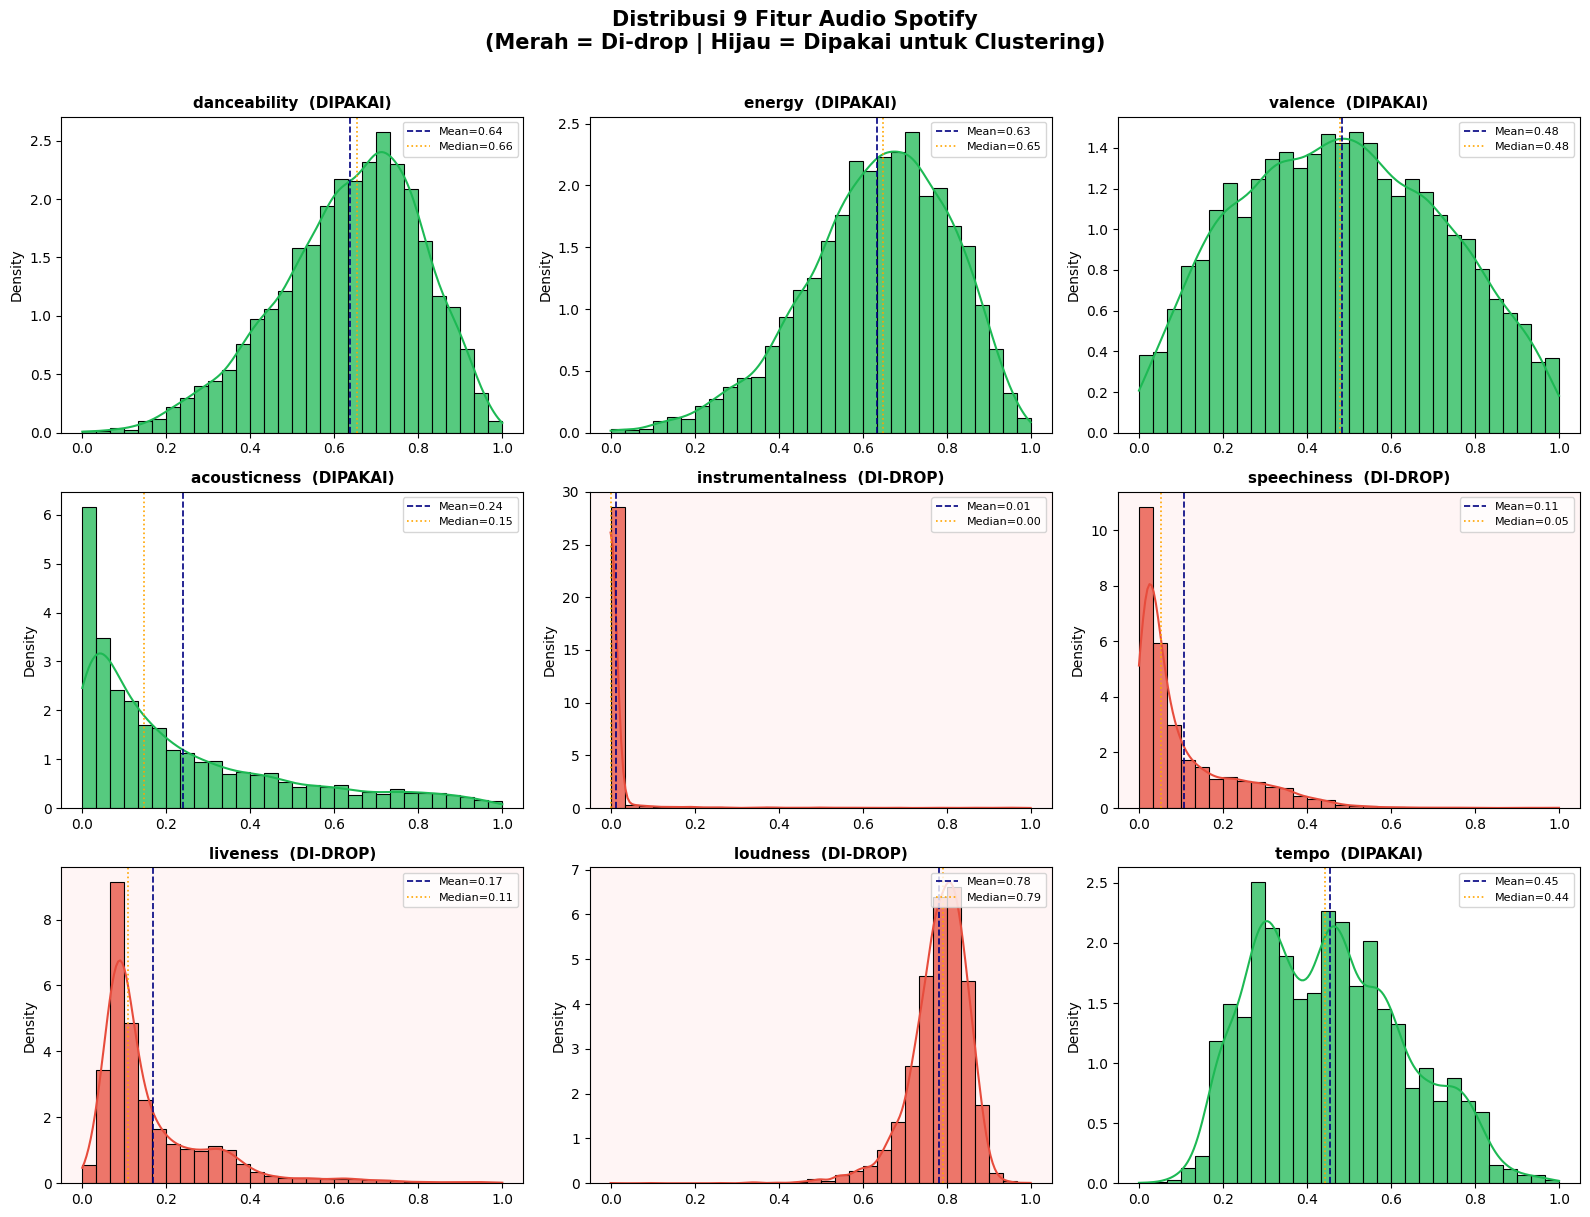

Plot distribusi disimpan → cluster/distribusi_9_fitur.png


In [6]:
# 9 fitur Spotify yang dianalisis
ALL_FEATURES    = ['danceability', 'energy', 'valence', 'acousticness',
                   'instrumentalness', 'speechiness', 'liveness', 'loudness', 'tempo']

# Fitur yang dipilih untuk clustering (5 fitur)
SELECTED_FEATURES = ['danceability', 'energy', 'valence', 'acousticness', 'tempo']

# Fitur yang di-drop
DROPPED_FEATURES  = ['instrumentalness', 'speechiness', 'liveness', 'loudness']

# Normalisasi tempo & loudness HANYA untuk visualisasi (agar skala sejajar)
df_viz = df.copy()
df_viz['tempo']    = df_viz['tempo']    / df_viz['tempo'].max()
df_viz['loudness'] = ((df_viz['loudness'] - df_viz['loudness'].min()) /
                      (df_viz['loudness'].max() - df_viz['loudness'].min()))

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(ALL_FEATURES):
    ax    = axes[i]
    color = '#e74c3c' if col in DROPPED_FEATURES else COLOR_GREEN
    bg    = '#FFF5F5'  if col in DROPPED_FEATURES else 'white'

    ax.set_facecolor(bg)
    sns.histplot(df_viz[col], kde=True, bins=30, color=color,
                 stat='density', ax=ax, alpha=0.75)

    label = '(DI-DROP)' if col in DROPPED_FEATURES else '(DIPAKAI)'
    ax.set_title(f'{col}  {label}', fontweight='bold', fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel('Density')

    # Statistik ringkas
    mu  = df_viz[col].mean()
    med = df_viz[col].median()
    ax.axvline(mu,  color='navy',   linestyle='--', linewidth=1.2, label=f'Mean={mu:.2f}')
    ax.axvline(med, color='orange', linestyle=':',  linewidth=1.2, label=f'Median={med:.2f}')
    ax.legend(fontsize=8, loc='upper right')

fig.suptitle(
    'Distribusi 9 Fitur Audio Spotify\n'
    '(Merah = Di-drop | Hijau = Dipakai untuk Clustering)',
    fontsize=15, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('../cluster/distribusi_9_fitur.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot distribusi disimpan → cluster/distribusi_9_fitur.png')

---
## 4. Heatmap Korelasi 9 Fitur Audio

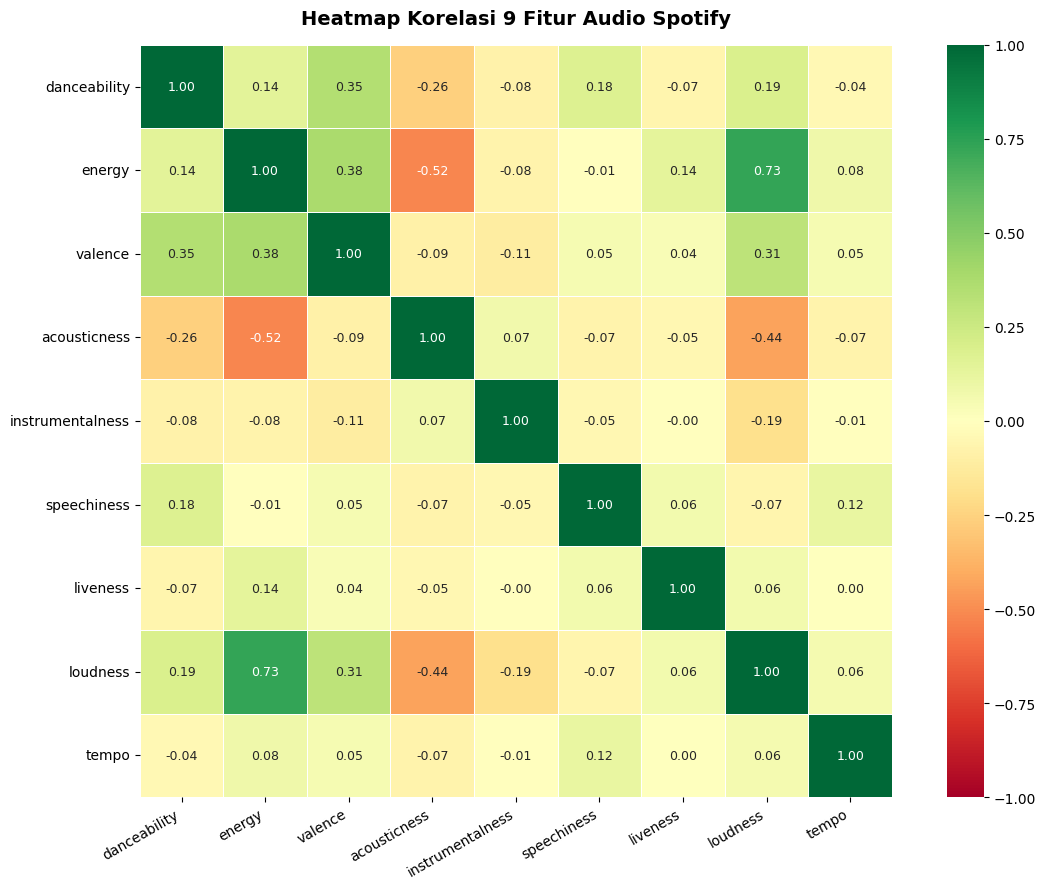


Pasangan fitur dengan korelasi tertinggi (|r| > 0.3):
     Fitur A      Fitur B  Korelasi
    loudness       energy  0.733578
acousticness       energy -0.518439
    loudness acousticness -0.435702
     valence       energy  0.380231
     valence danceability  0.350416
    loudness      valence  0.308961

Heatmap disimpan → cluster/heatmap_korelasi.png


In [8]:
corr = df[ALL_FEATURES].corr()

fig, ax = plt.subplots(figsize=(12, 9))

# Tampilkan full matrix (tanpa mask) agar mudah dibaca
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True,
    ax=ax,
    annot_kws={'size': 9}
)

ax.set_title('Heatmap Korelasi 9 Fitur Audio Spotify',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.savefig('../cluster/heatmap_korelasi.png', dpi=150, bbox_inches='tight')
plt.show()

# Pasangan korelasi tertinggi
print('\nPasangan fitur dengan korelasi tertinggi (|r| > 0.3):')
corr_pairs = (
    corr.where(np.tril(np.ones(corr.shape), k=-1).astype(bool))
        .stack()
        .reset_index()
)
corr_pairs.columns = ['Fitur A', 'Fitur B', 'Korelasi']
corr_pairs = corr_pairs.reindex(corr_pairs['Korelasi'].abs().sort_values(ascending=False).index)
print(corr_pairs[corr_pairs['Korelasi'].abs() > 0.3].to_string(index=False))
print('\nHeatmap disimpan → cluster/heatmap_korelasi.png')

---
## 5. Preprocessing: MinMaxScaler (5 Fitur Terpilih)

In [10]:
X_raw = df[SELECTED_FEATURES].copy()

print('=== Statistik SEBELUM scaling ===')
print(X_raw.describe().round(4))

scaler  = MinMaxScaler()
X_scaled = scaler.fit_transform(X_raw)
X_scaled_df = pd.DataFrame(X_scaled, columns=SELECTED_FEATURES)

print('\n=== Statistik SETELAH MinMaxScaler ===')
print(X_scaled_df.describe().round(4))

# Simpan scaler
joblib.dump(scaler, '../kmeans_cluster/scaler_cluster.pkl')
print('\nscaler_cluster.pkl disimpan → kmeans_cluster/scaler_cluster.pkl')

=== Statistik SEBELUM scaling ===
       danceability     energy    valence  acousticness      tempo
count     5494.0000  5494.0000  5494.0000     5494.0000  5494.0000
mean         0.6362     0.6349     0.4825        0.2394     0.4545
std          0.1705     0.1719     0.2385        0.2469     0.1768
min          0.0000     0.0000     0.0000        0.0000     0.0000
25%          0.5269     0.5285     0.2958        0.0458     0.3100
50%          0.6551     0.6495     0.4795        0.1459     0.4433
75%          0.7617     0.7632     0.6653        0.3652     0.5760
max          1.0000     1.0000     1.0000        1.0000     1.0000

=== Statistik SETELAH MinMaxScaler ===
       danceability     energy    valence  acousticness      tempo
count     5494.0000  5494.0000  5494.0000     5494.0000  5494.0000
mean         0.6362     0.6349     0.4825        0.2394     0.4545
std          0.1705     0.1719     0.2385        0.2469     0.1768
min          0.0000     0.0000     0.0000        0.0000

---
## 6. PCA: Reduksi Dimensi

=== Analisis PCA (n_components = 2, 3, 4) ===

PCA n=2: varians tertahan = 66.91%
  PC1: 40.84%
  PC2: 26.07%

PCA n=3: varians tertahan = 82.24%
  PC1: 40.84%
  PC2: 26.07%
  PC3: 15.33%

PCA n=4: varians tertahan = 93.72%
  PC1: 40.84%
  PC2: 26.07%
  PC3: 15.33%
  PC4: 11.48%



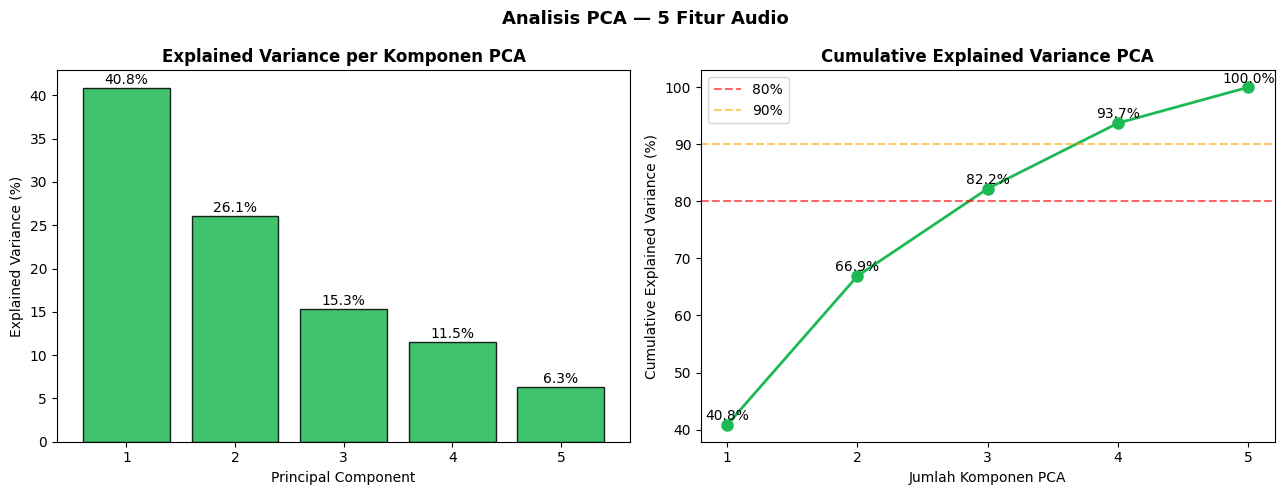


PCA 2D disimpan → kmeans_cluster/pca_5f.pkl
   Varians tertahan: 66.91%


In [11]:
print('=== Analisis PCA (n_components = 2, 3, 4) ===\n')

for n in [2, 3, 4]:
    pca_tmp = PCA(n_components=n, random_state=SEED)
    pca_tmp.fit(X_scaled)
    var_total = pca_tmp.explained_variance_ratio_.sum() * 100
    print(f'PCA n={n}: varians tertahan = {var_total:.2f}%')
    for i, v in enumerate(pca_tmp.explained_variance_ratio_):
        print(f'  PC{i+1}: {v*100:.2f}%')
    print()

# Scree Plot
pca_full = PCA(n_components=5, random_state=SEED)
pca_full.fit(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Explained variance per komponen
ax = axes[0]
ax.bar(range(1, 6), pca_full.explained_variance_ratio_ * 100,
       color=COLOR_GREEN, alpha=0.85, edgecolor='black')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance (%)')
ax.set_title('Explained Variance per Komponen PCA', fontweight='bold')
ax.set_xticks(range(1, 6))
for i, v in enumerate(pca_full.explained_variance_ratio_ * 100):
    ax.text(i + 1, v + 0.5, f'{v:.1f}%', ha='center', fontsize=10)

# Cumulative variance
ax = axes[1]
cumvar = np.cumsum(pca_full.explained_variance_ratio_) * 100
ax.plot(range(1, 6), cumvar, marker='o', color=COLOR_GREEN,
        linewidth=2, markersize=8)
ax.axhline(80, color='red',    linestyle='--', alpha=0.6, label='80%')
ax.axhline(90, color='orange', linestyle='--', alpha=0.6, label='90%')
ax.set_xlabel('Jumlah Komponen PCA')
ax.set_ylabel('Cumulative Explained Variance (%)')
ax.set_title('Cumulative Explained Variance PCA', fontweight='bold')
ax.set_xticks(range(1, 6))
ax.legend()
for i, v in enumerate(cumvar):
    ax.text(i + 1, v + 0.8, f'{v:.1f}%', ha='center', fontsize=10)

plt.suptitle('Analisis PCA — 5 Fitur Audio', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../kmeans_cluster/pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()

# Simpan PCA 2D (yang dipakai untuk clustering final)
pca_2d = PCA(n_components=2, random_state=SEED)
X_pca  = pca_2d.fit_transform(X_scaled)
joblib.dump(pca_2d, '../kmeans_cluster/pca_5f.pkl')
print(f'\nPCA 2D disimpan → kmeans_cluster/pca_5f.pkl')
print(f'   Varians tertahan: {pca_2d.explained_variance_ratio_.sum()*100:.2f}%')

---
## 7. Grid Search K Terbaik (Tanpa PCA & Dengan PCA)

In [13]:
print('======================================================')
print(' HASIL CLUSTERING DENGAN 5 FITUR AUDIO')
print(' (danceability, energy, valence, acousticness, tempo)')
print('======================================================\n')

results = []   # tampung semua hasil untuk perbandingan

# ── Tanpa PCA ────────────────────────────────────────
print('--- TANPA PCA ---')
best_k_raw, best_s_raw = 0, -1
for k in K_RANGE:
    km     = KMeans(n_clusters=k, random_state=SEED, n_init=N_INIT)
    labels = km.fit_predict(X_scaled)
    score  = silhouette_score(X_scaled, labels)
    print(f'K={k:2d} | Silhouette = {score:.4f}')
    results.append({'Setting': 'Tanpa PCA', 'K': k, 'Silhouette': round(score, 4)})
    if score > best_s_raw:
        best_k_raw, best_s_raw = k, score
print(f'>> TERBAIK TANPA PCA: K={best_k_raw} | Skor: {best_s_raw:.4f}\n')

# ── Dengan PCA (n_comp = 2, 3, 4) ────────────────────
print('--- DENGAN PCA ---')
best_overall = {'setting': '', 'k': 0, 'score': -1, 'X_pca': None, 'labels': None}

for n_comp in [2, 3, 4]:
    pca_tmp = PCA(n_components=n_comp, random_state=SEED)
    X_tmp   = pca_tmp.fit_transform(X_scaled)
    var_pct = pca_tmp.explained_variance_ratio_.sum() * 100

    print(f'\n[ PCA dengan {n_comp} Komponen Utama ]')
    print(f'Varians yang dipertahankan: {var_pct:.2f}%')

    best_k_pca, best_s_pca = 0, -1
    for k in K_RANGE:
        km     = KMeans(n_clusters=k, random_state=SEED, n_init=N_INIT)
        labels = km.fit_predict(X_tmp)
        score  = silhouette_score(X_tmp, labels)
        print(f'  K={k:2d} | Silhouette = {score:.4f}')
        results.append({
            'Setting': f'PCA n={n_comp} ({var_pct:.1f}%)',
            'K': k, 'Silhouette': round(score, 4)
        })
        if score > best_s_pca:
            best_k_pca, best_s_pca = k, score
        if score > best_overall['score']:
            best_overall.update({
                'setting': f'PCA n={n_comp}',
                'k': k, 'score': score,
                'X_pca': X_tmp.copy(),
                'labels': labels.copy()
            })

    print(f'>> TERBAIK PCA (n_comp={n_comp}): K={best_k_pca} | Skor: {best_s_pca:.4f}')

sep = '=' * 54
print(f'\n{sep}')
print(f' TERBAIK KESELURUHAN: {best_overall["setting"]}, '
      f'K={best_overall["k"]}, Silhouette={best_overall["score"]:.4f}')
print(sep)

# Simpan tabel hasil
results_df = pd.DataFrame(results)
print('\n📊 Tabel Lengkap Grid Search:')
print(results_df.to_string(index=False))

 HASIL CLUSTERING DENGAN 5 FITUR AUDIO
 (danceability, energy, valence, acousticness, tempo)

--- TANPA PCA ---
K= 3 | Silhouette = 0.2448
K= 4 | Silhouette = 0.2216
K= 5 | Silhouette = 0.2069
K= 6 | Silhouette = 0.1904
K= 7 | Silhouette = 0.1922
K= 8 | Silhouette = 0.1872
K= 9 | Silhouette = 0.1808
K=10 | Silhouette = 0.1763
>> TERBAIK TANPA PCA: K=3 | Skor: 0.2448

--- DENGAN PCA ---

[ PCA dengan 2 Komponen Utama ]
Varians yang dipertahankan: 66.91%
  K= 3 | Silhouette = 0.4175
  K= 4 | Silhouette = 0.4086
  K= 5 | Silhouette = 0.3695
  K= 6 | Silhouette = 0.3684
  K= 7 | Silhouette = 0.3673
  K= 8 | Silhouette = 0.3716
  K= 9 | Silhouette = 0.3527
  K=10 | Silhouette = 0.3531
>> TERBAIK PCA (n_comp=2): K=3 | Skor: 0.4175

[ PCA dengan 3 Komponen Utama ]
Varians yang dipertahankan: 82.24%
  K= 3 | Silhouette = 0.3157
  K= 4 | Silhouette = 0.2886
  K= 5 | Silhouette = 0.2808
  K= 6 | Silhouette = 0.2605
  K= 7 | Silhouette = 0.2648
  K= 8 | Silhouette = 0.2598
  K= 9 | Silhouette = 0

---
## Cell 8 — Silhouette Plot (Elbow + Silhouette Score per K)

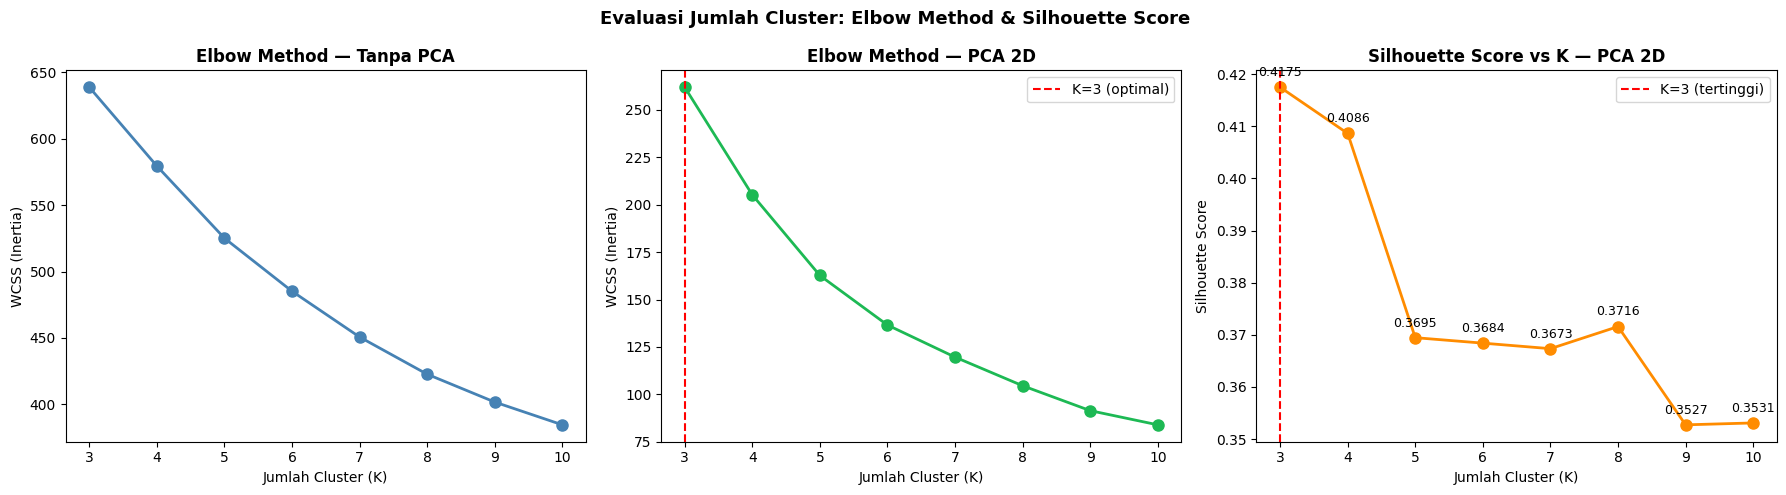

Plot disimpan → kmeans_cluster/elbow_silhouette_plot.png


In [14]:
# ── Elbow Plot (WCSS) ────────────────────────────────
wcss_raw, wcss_pca = [], []
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=N_INIT)
    km.fit(X_scaled)
    wcss_raw.append(km.inertia_)

    km2 = KMeans(n_clusters=k, random_state=SEED, n_init=N_INIT)
    km2.fit(X_pca)
    wcss_pca.append(km2.inertia_)

# ── Silhouette Score per K (PCA 2D) ──────────────────
sil_pca = []
for k in K_RANGE:
    km     = KMeans(n_clusters=k, random_state=SEED, n_init=N_INIT)
    labels = km.fit_predict(X_pca)
    sil_pca.append(silhouette_score(X_pca, labels))

k_list = list(K_RANGE)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1 — Elbow (tanpa PCA)
ax = axes[0]
ax.plot(k_list, wcss_raw, marker='o', color='steelblue', linewidth=2, markersize=8)
ax.set_title('Elbow Method — Tanpa PCA', fontweight='bold')
ax.set_xlabel('Jumlah Cluster (K)')
ax.set_ylabel('WCSS (Inertia)')
ax.set_xticks(k_list)

# Plot 2 — Elbow (PCA 2D)
ax = axes[1]
ax.plot(k_list, wcss_pca, marker='o', color=COLOR_GREEN, linewidth=2, markersize=8)
ax.axvline(x=3, color='red', linestyle='--', linewidth=1.5, label='K=3 (optimal)')
ax.set_title('Elbow Method — PCA 2D', fontweight='bold')
ax.set_xlabel('Jumlah Cluster (K)')
ax.set_ylabel('WCSS (Inertia)')
ax.set_xticks(k_list)
ax.legend()

# Plot 3 — Silhouette Score (PCA 2D)
ax = axes[2]
ax.plot(k_list, sil_pca, marker='o', color='darkorange', linewidth=2, markersize=8)
ax.axvline(x=3, color='red', linestyle='--', linewidth=1.5, label='K=3 (tertinggi)')
for k, s in zip(k_list, sil_pca):
    ax.annotate(f'{s:.4f}', (k, s), textcoords='offset points',
                xytext=(0, 8), ha='center', fontsize=9)
ax.set_title('Silhouette Score vs K — PCA 2D', fontweight='bold')
ax.set_xlabel('Jumlah Cluster (K)')
ax.set_ylabel('Silhouette Score')
ax.set_xticks(k_list)
ax.legend()

plt.suptitle('Evaluasi Jumlah Cluster: Elbow Method & Silhouette Score',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../kmeans_cluster/elbow_silhouette_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot disimpan → kmeans_cluster/elbow_silhouette_plot.png')

---
## 9. Clustering Final: KMeans K=3 pada PCA 2D

In [15]:
# Clustering final dengan konfigurasi terbaik: PCA n=2, K=3
kmeans_final = KMeans(n_clusters=3, random_state=SEED, n_init=N_INIT)
labels_final = kmeans_final.fit_predict(X_pca)

sil_final = silhouette_score(X_pca, labels_final)
print(f'✅ Clustering final selesai.')
print(f'   Konfigurasi : PCA n=2, K=3')
print(f'   Silhouette  : {sil_final:.4f}')
print(f'   Distribusi  :')
unique, counts = np.unique(labels_final, return_counts=True)
for c, n in zip(unique, counts):
    print(f'     Cluster {c}: {n:,} lagu ({n/len(labels_final)*100:.1f}%)')

# Simpan model KMeans
joblib.dump(kmeans_final, '../kmeans_cluster/kmeans_5f.pkl')
print('\nkmeans_5f.pkl disimpan → kmeans_cluster/kmeans_5f.pkl')

✅ Clustering final selesai.
   Konfigurasi : PCA n=2, K=3
   Silhouette  : 0.4175
   Distribusi  :
     Cluster 0: 2,263 lagu (41.2%)
     Cluster 1: 2,231 lagu (40.6%)
     Cluster 2: 1,000 lagu (18.2%)

kmeans_5f.pkl disimpan → kmeans_cluster/kmeans_5f.pkl


---
## 10. Interpretasi Cluster (Berdasarkan Distribusi Fitur Audio)

In [16]:
# Gabungkan label cluster ke dataframe ASLI (nilai sebelum scaling)
df_result = df.copy()
df_result['cluster_5f'] = labels_final

cluster_means = df_result.groupby('cluster_5f')[SELECTED_FEATURES].mean()
cluster_std   = df_result.groupby('cluster_5f')[SELECTED_FEATURES].std()
cluster_count = df_result['cluster_5f'].value_counts().sort_index()

print('======================================================')
print(' INTERPRETASI CLUSTER — DISTRIBUSI FITUR AUDIO')
print(' (nilai rata-rata fitur SEBELUM scaling/normalisasi)')
print('======================================================\n')

for cid in sorted(df_result['cluster_5f'].unique()):
    row_mean = cluster_means.loc[cid]
    row_std  = cluster_std.loc[cid]
    n_songs  = cluster_count[cid]

    print(f'┌─ Cluster {cid} ({n_songs:,} lagu, {n_songs/len(df_result)*100:.1f}%) ─────────────────────')
    print(f'│  danceability  : {row_mean["danceability"]:.4f}  ± {row_std["danceability"]:.4f}')
    print(f'│  energy        : {row_mean["energy"]:.4f}  ± {row_std["energy"]:.4f}')
    print(f'│  valence       : {row_mean["valence"]:.4f}  ± {row_std["valence"]:.4f}')
    print(f'│  acousticness  : {row_mean["acousticness"]:.4f}  ± {row_std["acousticness"]:.4f}')
    print(f'│  tempo (BPM)   : {row_mean["tempo"]:.2f}  ± {row_std["tempo"]:.2f}')
    print(f'└────────────────────────────────────────────────────')

    # Interpretasi berbasis distribusi, bukan judgement subjektif
    desc = []
    gm = cluster_means.mean()  # rata-rata global antar cluster

    if row_mean['danceability'] > gm['danceability'] + 0.03:
        desc.append(f'danceability TINGGI ({row_mean["danceability"]:.3f})')
    elif row_mean['danceability'] < gm['danceability'] - 0.03:
        desc.append(f'danceability RENDAH ({row_mean["danceability"]:.3f})')
    else:
        desc.append(f'danceability SEDANG ({row_mean["danceability"]:.3f})')

    if row_mean['energy'] > gm['energy'] + 0.05:
        desc.append(f'energy TINGGI ({row_mean["energy"]:.3f})')
    elif row_mean['energy'] < gm['energy'] - 0.05:
        desc.append(f'energy RENDAH ({row_mean["energy"]:.3f})')
    else:
        desc.append(f'energy SEDANG ({row_mean["energy"]:.3f})')

    if row_mean['valence'] > gm['valence'] + 0.05:
        desc.append(f'valence TINGGI ({row_mean["valence"]:.3f})')
    elif row_mean['valence'] < gm['valence'] - 0.05:
        desc.append(f'valence RENDAH ({row_mean["valence"]:.3f})')
    else:
        desc.append(f'valence SEDANG ({row_mean["valence"]:.3f})')

    if row_mean['acousticness'] > gm['acousticness'] + 0.05:
        desc.append(f'acousticness TINGGI ({row_mean["acousticness"]:.3f})')
    elif row_mean['acousticness'] < gm['acousticness'] - 0.05:
        desc.append(f'acousticness RENDAH ({row_mean["acousticness"]:.3f})')
    else:
        desc.append(f'acousticness SEDANG ({row_mean["acousticness"]:.3f})')

    if row_mean['tempo'] > gm['tempo'] + 5:
        desc.append(f'tempo CEPAT ({row_mean["tempo"]:.1f} BPM)')
    elif row_mean['tempo'] < gm['tempo'] - 5:
        desc.append(f'tempo LAMBAT ({row_mean["tempo"]:.1f} BPM)')
    else:
        desc.append(f'tempo SEDANG ({row_mean["tempo"]:.1f} BPM)')

    print(f'   → Karakteristik: {", ".join(desc)}\n')

print('\nTABEL RINGKASAN RATA-RATA FITUR PER CLUSTER:')
print(cluster_means.round(4).to_string())

 INTERPRETASI CLUSTER — DISTRIBUSI FITUR AUDIO
 (nilai rata-rata fitur SEBELUM scaling/normalisasi)

┌─ Cluster 0 (2,263 lagu, 41.2%) ─────────────────────
│  danceability  : 0.7142  ± 0.1279
│  energy        : 0.7180  ± 0.1292
│  valence       : 0.7053  ± 0.1320
│  acousticness  : 0.1777  ± 0.1580
│  tempo (BPM)   : 0.47  ± 0.17
└────────────────────────────────────────────────────
   → Karakteristik: danceability TINGGI (0.714), energy TINGGI (0.718), valence TINGGI (0.705), acousticness RENDAH (0.178), tempo SEDANG (0.5 BPM)

┌─ Cluster 1 (2,231 lagu, 40.6%) ─────────────────────
│  danceability  : 0.6104  ± 0.1676
│  energy        : 0.6412  ± 0.1380
│  valence       : 0.3126  ± 0.1353
│  acousticness  : 0.1128  ± 0.1079
│  tempo (BPM)   : 0.46  ± 0.18
└────────────────────────────────────────────────────
   → Karakteristik: danceability SEDANG (0.610), energy SEDANG (0.641), valence RENDAH (0.313), acousticness RENDAH (0.113), tempo SEDANG (0.5 BPM)

┌─ Cluster 2 (1,000 lagu, 18.2%

---
## 11. Visualisasi Cluster (Scatter PCA 2D + Silhouette Diagram)

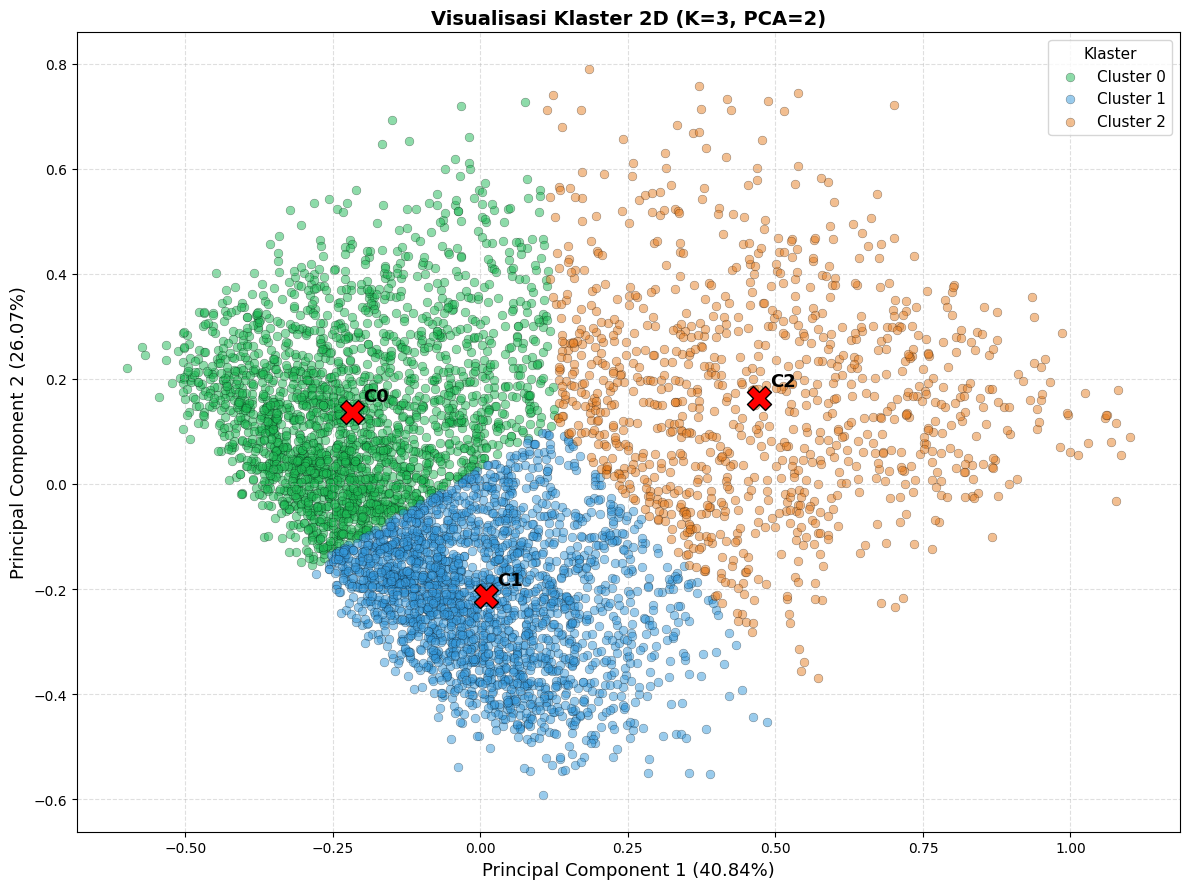

✅ Plot disimpan → kmeans_cluster/scatter_cluster_2d.png


In [20]:
COLORS = {0: '#1DB954', 1: '#3498db', 2: '#e67e22'}

fig, ax = plt.subplots(figsize=(12, 9))

for cid in sorted(np.unique(labels_final)):
    mask = labels_final == cid
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=COLORS[cid], alpha=0.5, s=40,
        label=f'Cluster {cid}', edgecolors='black', linewidths=0.3
    )
    cx, cy = X_pca[mask, 0].mean(), X_pca[mask, 1].mean()
    ax.scatter(cx, cy, c='red', s=300, marker='X',
               edgecolors='black', linewidths=1.0, zorder=5)
    ax.annotate(f'C{cid}', (cx, cy), fontsize=13,
                fontweight='bold', color='black',
                xytext=(8, 8), textcoords='offset points')

var = pca_2d.explained_variance_ratio_
ax.set_xlabel(f'Principal Component 1 ({var[0]*100:.2f}%)', fontsize=13)
ax.set_ylabel(f'Principal Component 2 ({var[1]*100:.2f}%)', fontsize=13)
ax.set_title('Visualisasi Klaster 2D (K=3, PCA=2)', fontweight='bold', fontsize=14)
ax.legend(title='Klaster', fontsize=11, title_fontsize=11)
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('../kmeans_cluster/scatter_cluster_2d.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot disimpan → kmeans_cluster/scatter_cluster_2d.png')

---
## 12. Bar Chart Rata-rata Fitur Audio per Cluster

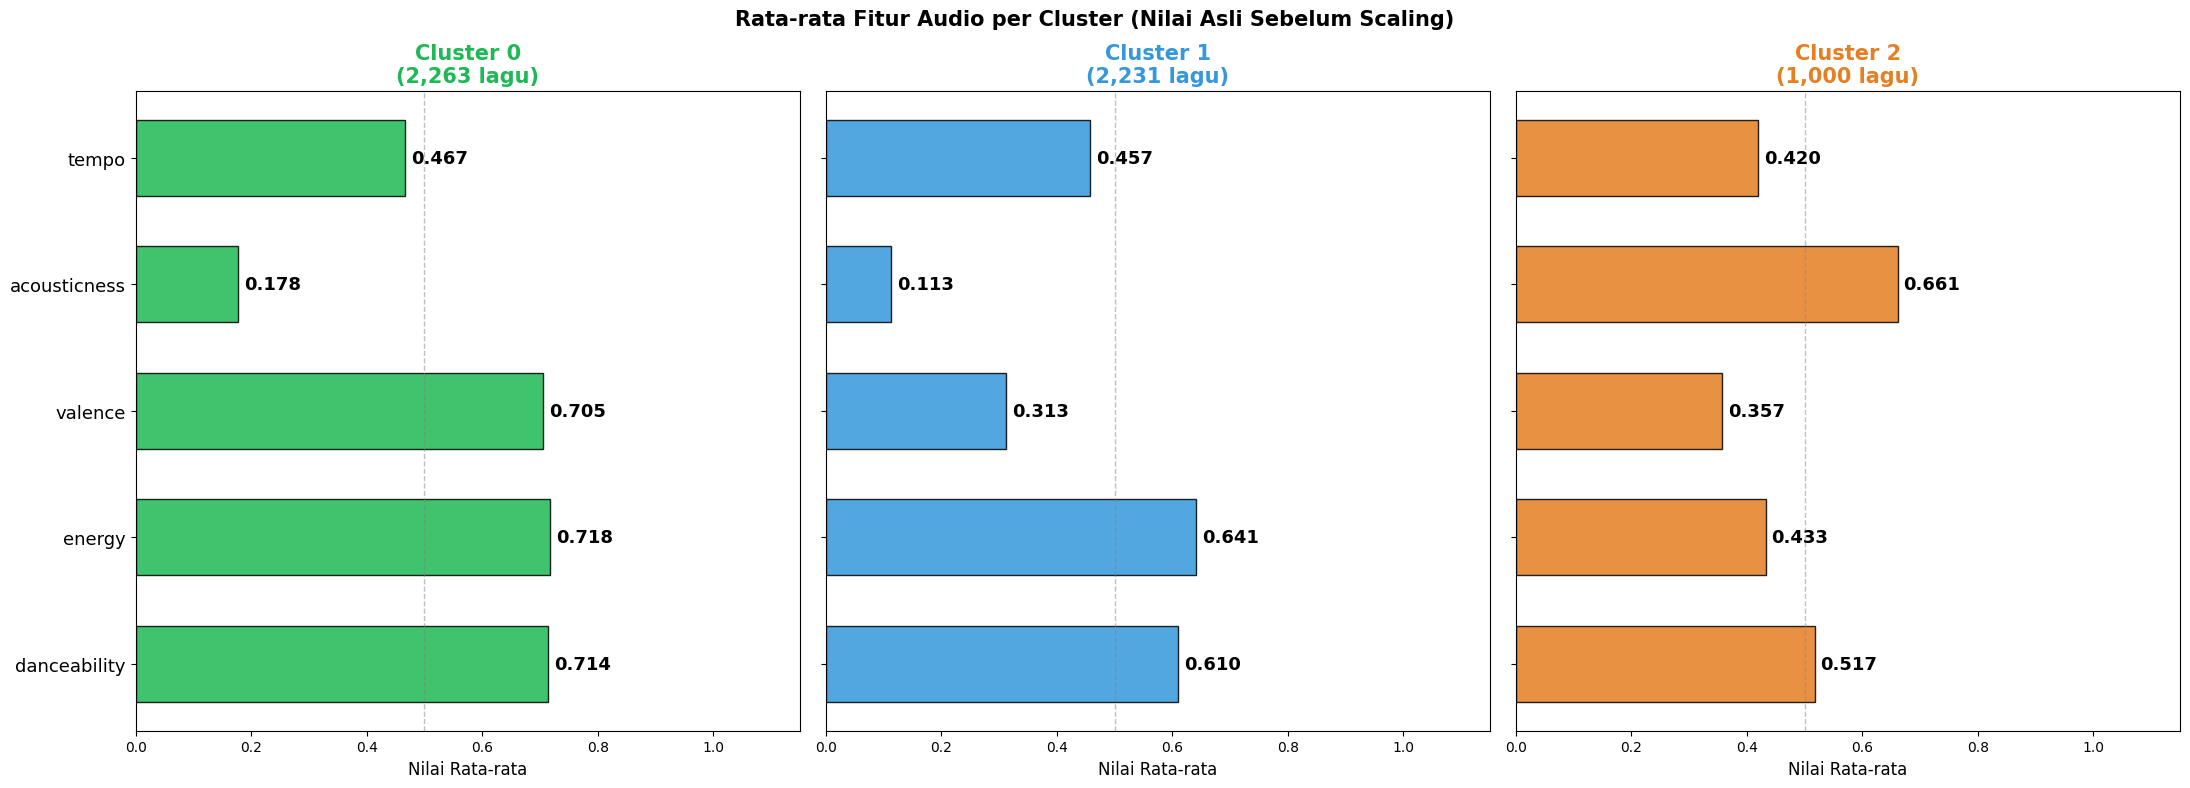

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(22, 8), sharey=True)

for cid in sorted(df_result['cluster_5f'].unique()):
    ax      = axes[cid]
    vals    = cluster_means.loc[cid, SELECTED_FEATURES]
    color   = COLORS[cid]
    n_songs = cluster_count[cid]

    bars = ax.barh(SELECTED_FEATURES, vals, color=color,
                   alpha=0.85, edgecolor='black', height=0.6)

    for bar, val in zip(bars, vals):
        ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
                f'{val:.3f}', va='center', fontsize=13, fontweight='bold')

    ax.set_xlim(0, 1.15)
    ax.set_title(f'Cluster {cid}\n({n_songs:,} lagu)',
                 fontweight='bold', color=color, fontsize=15)
    ax.set_xlabel('Nilai Rata-rata', fontsize=12)
    ax.tick_params(axis='y', labelsize=13)
    ax.axvline(0.5, color='grey', linestyle='--', alpha=0.5, linewidth=1)

plt.suptitle('Rata-rata Fitur Audio per Cluster (Nilai Asli Sebelum Scaling)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../kmeans_cluster/fitur_per_cluster.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 13. Simpan Output Final

In [27]:
# Simpan hanya kolom yang dibutuhkan
COLS_SAVE = [
    'item_id', 'track_id', 'track_name', 'artist_names',
    'danceability', 'energy', 'valence', 'acousticness', 'tempo',
    'cluster_5f'
]

df_save = df_result[COLS_SAVE].copy()
df_save.to_csv('../kmeans_cluster/item_dataset_5f.csv', index=False)

# Verifikasi
print('==============================================')
print('   FILE BERHASIL DISIMPAN')
print('==============================================')
print(f'  ../kmeans_cluster/item_dataset_5f.csv  ({len(df_save):,} baris)')
print(f'  Kolom: {df_save.columns.tolist()}')
print()
print('Cek item_id:')
print(f'   min={df_save["item_id"].min()}, max={df_save["item_id"].max()}, unique={df_save["item_id"].nunique()}')
print()
print('Distribusi cluster_5f:')
print(df_save['cluster_5f'].value_counts().sort_index().to_string())
print()
print('Sample 5 baris:')
df_save[['item_id', 'track_name', 'artist_names', 'cluster_5f']].head()

   FILE BERHASIL DISIMPAN
  ../kmeans_cluster/item_dataset_5f.csv  (5,494 baris)
  Kolom: ['item_id', 'track_id', 'track_name', 'artist_names', 'danceability', 'energy', 'valence', 'acousticness', 'tempo', 'cluster_5f']

Cek item_id:
   min=0, max=5493, unique=5494

Distribusi cluster_5f:
cluster_5f
0    2263
1    2231
2    1000

Sample 5 baris:


,item_id,track_name,artist_names,cluster_5f
0,0,still got time feat partynextdoor,zayn partynextdoor,0
1,1,growing pains,alessia cara,1
2,2,mr brightside,the killers,1
3,3,best life feat chance the rapper,cardi b chance the rapper,0
4,4,one right now with the weeknd,post malone the weeknd,0


In [2]:
import pandas as pd

train_df = pd.read_csv("../data/train_dataset.csv")
test_df = pd.read_csv("../data/test_dataset.csv")
item_5f = pd.read_csv("../kmeans_cluster/item_dataset_5f.csv")

print(train_df.head())
print(item_5f[["item_id", "cluster_5f"]].head())

   user_id_enc  item_id_enc  label
0            0           70      1
1            0         3865      0
2            0         2075      0
3            0           96      0
4            0          948      0
   item_id  cluster_5f
0        0           0
1        1           1
2        2           1
3        3           0
4        4           0


In [3]:
print("Item ID min-max:", item_5f["item_id"].min(), item_5f["item_id"].max())
print("Cluster unik:", sorted(item_5f["cluster_5f"].unique()))
print("Jumlah item unik:", item_5f["item_id"].nunique())

Item ID min-max: 0 5493
Cluster unik: [0, 1, 2]
Jumlah item unik: 5494


In [4]:
cluster_map = item_5f[["item_id", "cluster_5f"]].copy()

train_cluster = train_df.merge(
    cluster_map,
    left_on="item_id_enc",
    right_on="item_id",
    how="left"
)

test_cluster = test_df.merge(
    cluster_map,
    left_on="item_id_enc",
    right_on="item_id",
    how="left"
)

In [5]:
train_cluster = train_cluster.drop(columns=["item_id"])
test_cluster = test_cluster.drop(columns=["item_id"])

train_cluster["cluster_5f"] = train_cluster["cluster_5f"].fillna(0).astype(int)
test_cluster["cluster_5f"] = test_cluster["cluster_5f"].fillna(0).astype(int)

In [6]:
print(train_cluster.head())
print(test_cluster.head())

print(train_cluster["cluster_5f"].value_counts())
print(test_cluster["cluster_5f"].value_counts())

assert train_cluster["cluster_5f"].isin([0, 1, 2]).all()
assert test_cluster["cluster_5f"].isin([0, 1, 2]).all()
assert train_cluster["cluster_5f"].isna().sum() == 0
assert test_cluster["cluster_5f"].isna().sum() == 0

   user_id_enc  item_id_enc  label  cluster_5f
0            0           70      1           0
1            0         3865      0           0
2            0         2075      0           0
3            0           96      0           1
4            0          948      0           1
   user_id_enc  item_id_enc  label  cluster_5f
0            0          619      1           1
1            0          206      0           1
2            0         2270      0           1
3            0         2022      0           1
4            0         1842      0           1
cluster_5f
1    1129148
0    1121588
2     507754
Name: count, dtype: int64
cluster_5f
1    391775
0    384985
2    176140
Name: count, dtype: int64


In [7]:
assert train_cluster["cluster_5f"].isna().sum() == 0
assert test_cluster["cluster_5f"].isna().sum() == 0

assert train_cluster["cluster_5f"].isin([0, 1, 2]).all()
assert test_cluster["cluster_5f"].isin([0, 1, 2]).all()

print(train_cluster.shape)
print(test_cluster.shape)

(2758490, 4)
(952900, 4)


In [8]:
train_cluster.to_csv("../data/train_dataset_cluster_5f.csv", index=False)
test_cluster.to_csv("../data/test_dataset_cluster_5f.csv", index=False)